In [1]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import math

In [10]:
# =========================
# 1. Load GPS / XY Data
# =========================
def load_track_points(csv_path):
    """
    Supports either:
    - x_m, y_m (already in meters)
    - lat, lon (degrees)
    Returns x, y in meters.
    """
    df = pd.read_csv(csv_path)

    if {"x_m", "y_m"}.issubset(df.columns):
        return df["x_m"].values, df["y_m"].values

    if {"lat", "lon"}.issubset(df.columns):
        return latlon_to_xy(df["lat"].values, df["lon"].values)

    raise ValueError(
        "CSV must contain either columns (x_m, y_m) or (lat, lon). "
        f"Found: {list(df.columns)}"
    )


# =========================
# 2. Convert lat/lon -> meters (local projection)
# =========================
def latlon_to_xy(lat, lon):
    """
    Equirectangular approximation (good enough for small tracks).
    """
    R = 6371000  # Earth radius (meters)
    lat0 = np.mean(lat)

    x = R * np.radians(lon) * np.cos(np.radians(lat0))
    y = R * np.radians(lat)

    return x, y


# =========================
# 3. Smooth path
# =========================
def smooth_path(x, y, window=11, poly=3):
    # Ensure odd window and keep it valid for short tracks
    n = len(x)
    if n < 5:
        return x, y

    w = min(window, n if n % 2 == 1 else n - 1)
    if w < 5:
        return x, y
    if w % 2 == 0:
        w -= 1

    p = min(poly, w - 1)

    x_smooth = savgol_filter(x, w, p)
    y_smooth = savgol_filter(y, w, p)
    return x_smooth, y_smooth


# =========================
# 4. Compute cumulative distance
# =========================
def compute_distance(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)
    cum_dist = np.insert(np.cumsum(dist), 0, 0)
    return cum_dist


# =========================
# 5. Compute curvature
# =========================
def compute_curvature(x, y):
    """
    Using finite differences
    """
    dx = np.gradient(x)
    dy = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    denom = (dx**2 + dy**2) ** 1.5
    curvature = np.divide(
        np.abs(dx * ddy - dy * ddx),
        denom,
        out=np.zeros_like(dx, dtype=float),
        where=denom > 1e-12,
    )
    return np.nan_to_num(curvature)


# =========================
# 6. Segment the track
# =========================


#### Original segmentation based on average curvature per segment with simple thresholds

# def create_segments(x, y, cum_dist, curvature, target_seg_len=200):
#     if target_seg_len <= 0:
#         raise ValueError("target_seg_len must be > 0")

#     segments = []
#     start_idx = 0
#     N = len(cum_dist)

#     while start_idx < N - 1:
#         start_dist = cum_dist[start_idx]
#         # print(start_dist)

#         # find end index
#         end_idx = start_idx
#         while end_idx < N and (cum_dist[end_idx] - start_dist) < target_seg_len:
#             end_idx += 1

#         end_idx = min(end_idx, N - 1)
#         # print(end_idx)
#         # Guarantee forward progress even on degenerate/duplicate points
#         if end_idx <= start_idx:
#             end_idx = min(start_idx + 1, N - 1)

#         seg_slice = slice(start_idx, end_idx + 1)

#         seg_length = float(cum_dist[end_idx] - cum_dist[start_idx])
#         avg_curv = float(np.mean(curvature[seg_slice]))

#         # classify segment
#         if avg_curv < 0.0003:
#             seg_type = "straight"
#         elif avg_curv < 0.01:
#             seg_type = "fast_corner"
#         else:
#             seg_type = "tight_corner"

#         # regen/deploy heuristics
#         regen_weight = 1.0 if seg_type != "straight" else 0.2
#         deploy_weight = 1.0 if seg_type == "straight" else 0.4

#         segment = {
#             "start_idx": int(start_idx),
#             "end_idx": int(end_idx),
#             "length": seg_length,
#             "curvature": avg_curv,
#             "type": seg_type,
#             "regen_weight": float(regen_weight),
#             "deploy_weight": float(deploy_weight),
#         }

#         segments.append(segment)
#         start_idx = end_idx

#     return segments


#### Improved segmentation using curvature-based speed limits and hysteresis to reduce flicker near boundaries
def create_segments_speed_based(
    x,
    y,
    cum_dist,
    curvature,
    target_seg_len=50,
    kappa_straight=3e-4,
    ay_max=24.0,
    hs_speed_mps=55.0,
    curv_percentile=85,
    straight_hysteresis=0.70,
    corner_hysteresis=1.05,
):
    """
    Segment and classify using:
      v_max = sqrt(a_y_max / kappa_seg)
    where kappa_seg is a robust percentile curvature per segment.

    Classes:
      - straight
      - high_speed_corner
      - low_speed_corner
    """
    if target_seg_len <= 0:
        raise ValueError("target_seg_len must be > 0")
    if ay_max <= 0:
        raise ValueError("ay_max must be > 0")
    if hs_speed_mps <= 0:
        raise ValueError("hs_speed_mps must be > 0")
    if not (0 <= curv_percentile <= 100):
        raise ValueError("curv_percentile must be in [0, 100]")

    segments = []
    start_idx = 0
    n = len(cum_dist)

    while start_idx < n - 1:
        start_dist = cum_dist[start_idx]

        end_idx = start_idx
        while end_idx < n and (cum_dist[end_idx] - start_dist) < target_seg_len:
            end_idx += 1

        end_idx = min(end_idx, n - 1)
        if end_idx <= start_idx:
            end_idx = min(start_idx + 1, n - 1)

        seg_slice = slice(start_idx, end_idx + 1)
        seg_length = float(cum_dist[end_idx] - cum_dist[start_idx])

        seg_curv = np.asarray(curvature[seg_slice], dtype=float)
        seg_curv = np.nan_to_num(seg_curv, nan=0.0, posinf=0.0, neginf=0.0)

        # Robust curvature estimate for the segment
        kappa_seg = float(np.percentile(seg_curv, curv_percentile))

        # Convert curvature to speed feasibility
        kappa_safe = max(kappa_seg, 1e-9)
        vmax_seg = float(np.sqrt(ay_max / kappa_safe))

        # Two-threshold logic to reduce flicker near boundaries
        straight_enter = kappa_straight * straight_hysteresis
        corner_enter = hs_speed_mps * corner_hysteresis

        if kappa_seg < straight_enter:
            seg_type = "straight"
        elif vmax_seg > corner_enter:
            seg_type = "high_speed_corner"
        else:
            seg_type = "low_speed_corner"

        regen_weight = 0.2 if seg_type == "straight" else 1.0
        deploy_weight = 1.0 if seg_type == "straight" else 0.4

        aero_mode = 1 if seg_type == "straight" else 0

        segments.append(
            {
                "start_idx": int(start_idx),
                "end_idx": int(end_idx),
                "length": seg_length,
                "curvature_pctl": kappa_seg,
                "vmax_mps": vmax_seg,
                "type": seg_type,
                "regen_weight": float(regen_weight),
                "deploy_weight": float(deploy_weight),
                "aero_mode": int(aero_mode),
            }
        )

        start_idx = end_idx

    return segments



# =========================
# 7. Pipeline function
# =========================
def gps_to_rl_segments(
    csv_path,
    target_seg_len=50,
    kappa_straight=0.007,
    ay_max=30.0,
    hs_speed_mps=50.0,
    curv_percentile=90,
):
    x, y = load_track_points(csv_path)
    x, y = smooth_path(x, y)

    cum_dist = compute_distance(x, y)
    curvature = compute_curvature(x, y)

    segments = create_segments_speed_based(
        x,
        y,
        cum_dist,
        curvature,
        target_seg_len=target_seg_len,
        kappa_straight=kappa_straight,
        ay_max=ay_max,
        hs_speed_mps=hs_speed_mps,
        curv_percentile=curv_percentile,
    )
    return x, y, segments


# =========================
# 8. Example usage
# =========================
if __name__ == "__main__":
    csv_path = "D:/RL_Hackathon/src/envs/F1_26/track/Melbourne.csv"
    x2, y2, segments = gps_to_rl_segments(
        csv_path,
        target_seg_len=50,
        kappa_straight=0.007,
        ay_max=30.0,
        hs_speed_mps=50.0,
        curv_percentile=90,
    )

    print(f"Total segments: {len(segments)}")

    for i, seg in enumerate(segments[:5]):
        print(f"Segment {i}: {seg}")

Total segments: 96
Segment 0: {'start_idx': 0, 'end_idx': 11, 'length': 54.9623929086289, 'curvature_pctl': 3.048010905577831e-05, 'vmax_mps': 992.0929628400015, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
Segment 1: {'start_idx': 11, 'end_idx': 22, 'length': 54.962392348812045, 'curvature_pctl': 3.1839156491693835e-05, 'vmax_mps': 970.6884243064296, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
Segment 2: {'start_idx': 22, 'end_idx': 33, 'length': 54.962392629141064, 'curvature_pctl': 3.3196369707245875e-05, 'vmax_mps': 950.6383515377041, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
Segment 3: {'start_idx': 33, 'end_idx': 44, 'length': 54.962392559577694, 'curvature_pctl': 3.456031779289818e-05, 'vmax_mps': 931.6907070020922, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
Segment 4: {'start_idx': 44, 'end_idx': 55, 'length': 54.96239300650444, 'curvatur

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_track(x, y, segments):
    # Build cumulative distance for plotting segment boundaries
    dx = np.diff(x)
    dy = np.diff(y)
    seg_dist = np.insert(np.cumsum(np.sqrt(dx**2 + dy**2)), 0, 0)

    fig, axes = plt.subplots(2, 1, figsize=(18, 12))

    # --------------------------
    # 1) Original view (no equal-aspect top-down forcing)
    # --------------------------
    ax = axes[0]
    ax.plot(x, y, linewidth=2)
    ax.set_title("Track Centerline (Original View)")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.grid(True)

    # --------------------------
    # 2) Segment-colored view (supports old and new labels)
    # --------------------------
    ax = axes[1]
    color_map = {
        "straight": "green",
        "fast_corner": "orange",
        "tight_corner": "red",
        "high_speed_corner": "orange",
        "low_speed_corner": "red",
    }

    for seg in segments:
        s = seg["start_idx"]
        e = seg["end_idx"]
        seg_type = seg["type"]
        ax.plot(x[s:e+1], y[s:e+1], color=color_map.get(seg_type, "blue"), linewidth=3)

    ax.set_title("Segments by Type (Original View)")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_aspect("auto")
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()


Total segments: 96
First 3 segments:
{'start_idx': 0, 'end_idx': 11, 'length': 54.9623929086289, 'curvature_pctl': 3.048010905577831e-05, 'vmax_mps': 992.0929628400015, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
{'start_idx': 11, 'end_idx': 22, 'length': 54.962392348812045, 'curvature_pctl': 3.1839156491693835e-05, 'vmax_mps': 970.6884243064296, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}
{'start_idx': 22, 'end_idx': 33, 'length': 54.962392629141064, 'curvature_pctl': 3.3196369707245875e-05, 'vmax_mps': 950.6383515377041, 'type': 'straight', 'regen_weight': 0.2, 'deploy_weight': 1.0, 'aero_mode': 1}


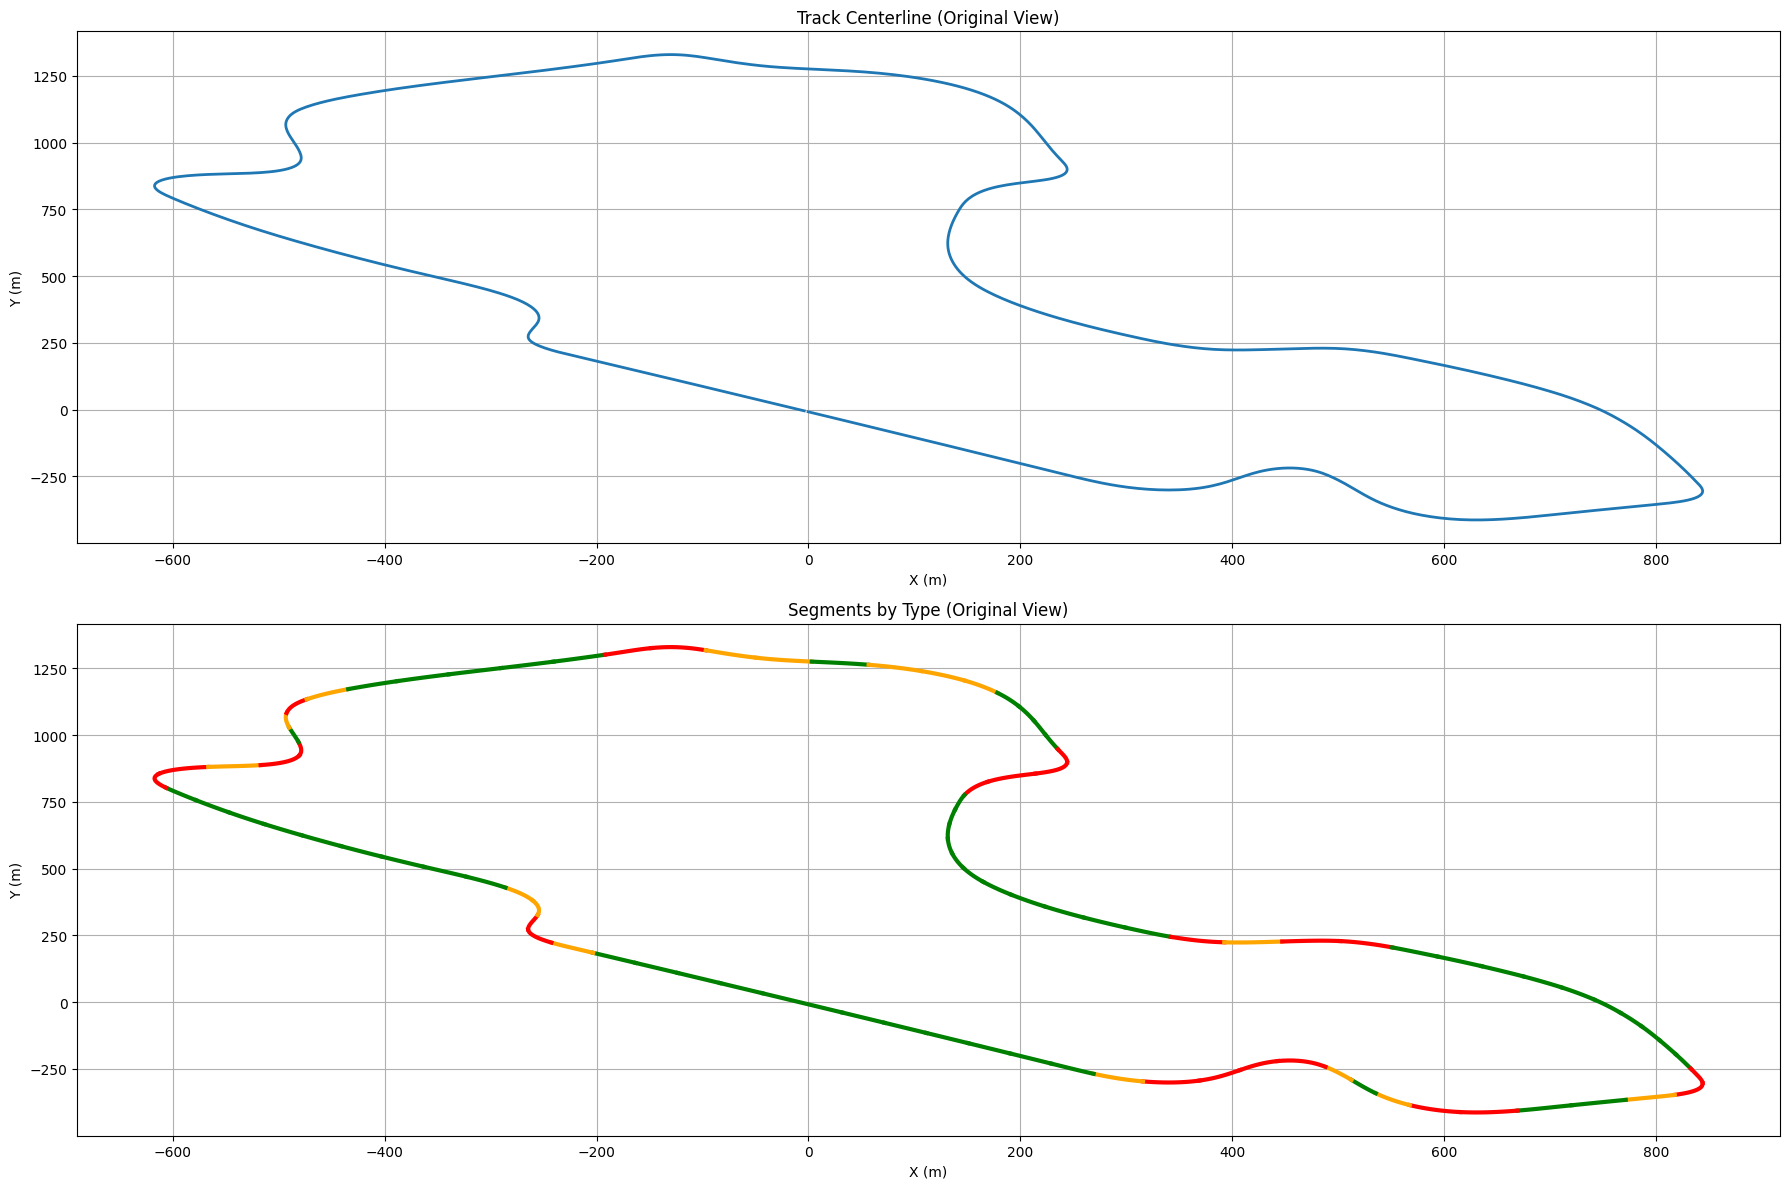

In [14]:
x, y, segments = gps_to_rl_segments("D:/RL_Hackathon/src/envs/F1_26/track/Melbourne.csv",
    target_seg_len=50,
    kappa_straight=0.007,
    ay_max=30.0,
    hs_speed_mps=50.0,
    curv_percentile=90,
    )

print(f"Total segments: {len(segments)}")
print("First 3 segments:")
for seg in segments[:3]:
    print(seg)

visualize_track(x, y, segments)